In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:
def get_clean_df(file_path):
    df = pd.read_csv(file_path)
    # Strip any hidden spaces from column names
    df.columns = df.columns.str.strip()
    
    # Automatically find the columns
    col_4bit = [c for c in df.columns if '4bit' in c and 'MIN' not in c and 'MAX' not in c]
    col_8bit = [c for c in df.columns if '8e' in c and 'MIN' not in c and 'MAX' not in c]
    
    if not col_4bit or not col_8bit:
        print(f"Warning: Could not find columns in {file_path}. Found: {df.columns.tolist()}")
        return None

    # Rename for the plot
    df = df.rename(columns={col_4bit[0]: '4-bit', col_8bit[0]: '8-bit'})
    
    # Replace 0s with a very small number to avoid blank log plots
    df['4-bit'] = df['4-bit'].replace(0, 1e-10)
    df['8-bit'] = df['8-bit'].replace(0, 1e-10)
    
    return df

In [22]:
df_attn = get_clean_df('delta_w_attention.csv')
df_mlp = get_clean_df('delta_w_mlp.csv')
# plt.rcParams.update({
#     "font.family": "serif",
#     "font.serif": ["Times New Roman"],
#     "text.usetex": False, # Set to True if you have a local LaTeX distribution installed
#     "axes.labelsize": 12,
#     "legend.fontsize": 10,
# })

In [15]:
df_attn.columns

Index(['Step', 'llama1b_u_r64-5e-6_8e_dataset1 - train/delta_W_attention',
       'llama1b_u_r64-5e-6_8e_dataset1 - train/delta_W_attention__MIN',
       'llama1b_u_r64-5e-6_8e_dataset1 - train/delta_W_attention__MAX',
       'llama1b-bnb-4bit_r64_3e-5_20ex_dataset1 - train/delta_W_attention',
       'llama1b-bnb-4bit_r64_3e-5_20ex_dataset1 - train/delta_W_attention__MIN',
       'llama1b-bnb-4bit_r64_3e-5_20ex_dataset1 - train/delta_W_attention__MAX'],
      dtype='str')

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

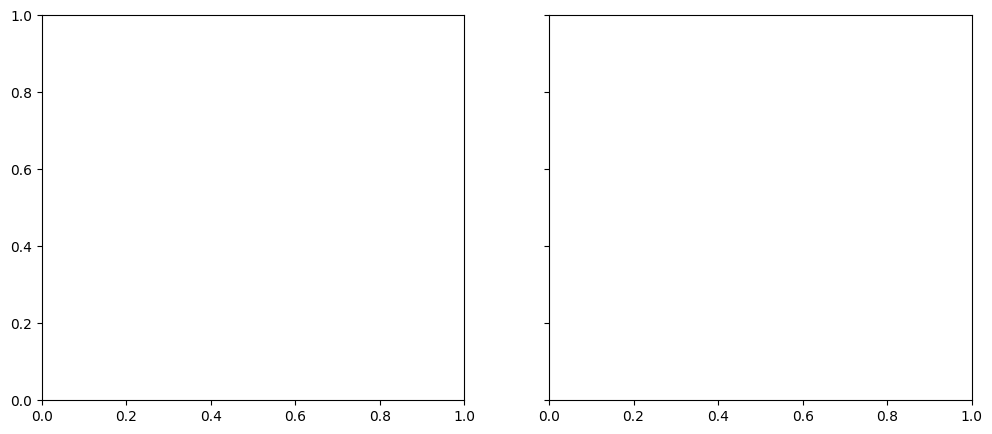

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
RTN_NF4 = 0.0625   # (0.125 / 2)
RTN_INT8 = 0.0039  # (0.0078 / 2)

In [17]:
column_map_attn = {
    'llama1b-bnb-4bit_r64_3e-5_20ex_dataset1 - train/delta_W_attention': '4-bit',
    'llama1b_u_r64-5e-6_8e_dataset1 - train/delta_W_attention': '8-bit'
}

column_map_mlp = {
    'llama1b-bnb-4bit_r64_3e-5_20ex_dataset1 - train/delta_W_mlp': '4-bit',
    'llama1b_u_r64-5e-6_8e_dataset1 - train/delta_W_mlp': '8-bit'
}

# Rename the columns in the dataframes
df_attn = df_attn.rename(columns=column_map_attn)
df_mlp = df_mlp.rename(columns=column_map_mlp)

In [18]:
df_attn.columns

Index(['Step', '8-bit',
       'llama1b_u_r64-5e-6_8e_dataset1 - train/delta_W_attention__MIN',
       'llama1b_u_r64-5e-6_8e_dataset1 - train/delta_W_attention__MAX',
       '4-bit',
       'llama1b-bnb-4bit_r64_3e-5_20ex_dataset1 - train/delta_W_attention__MIN',
       'llama1b-bnb-4bit_r64_3e-5_20ex_dataset1 - train/delta_W_attention__MAX'],
      dtype='str')

In [24]:
def plot_updates(ax, df, title):
    if df is None: return
    
    # Plot data
    ax.plot(df['Step'], df['4-bit'], label='4-bit |ΔW|', color='#8c564b', lw=1.2, alpha=0.7) 
    ax.plot(df['Step'], df['8-bit'], label='8-bit |ΔW|', color='#7f7f7f', lw=1.2, alpha=0.9) 
    
    # Plot threshold lines
    ax.axhline(y=RTN_NF4, color='red', linestyle='--', linewidth=2, label='NF4 Rounding Limit')
    ax.axhline(y=RTN_INT8, color='blue', linestyle='--', linewidth=2, label='INT8 Rounding Limit')
    
    ax.set_yscale('log')
    # Force Y-axis limits to ensure data and thresholds are both visible
    ax.set_ylim(1e-9, 1) 
    
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Training Steps')
    ax.grid(True, which="both", ls="-", alpha=0.15)

In [26]:
plot_updates(ax1, df_attn, "(a) Attention Layer Updates")
ax1.set_ylabel("Update Magnitude |ΔW| (Log Scale)")

plot_updates(ax2, df_mlp, "(b) MLP Layer Updates")

# Legend placement
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4, frameon=False)

plt.tight_layout()
plt.savefig('figure1_discretization_bottleneck.png', bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>


--- Checking delta_w_attention.csv ---
Found 4-bit column: ['llama1b-bnb-4bit_r64_3e-5_20ex_dataset1 - train/delta_W_attention']
Found 8-bit column: ['llama1b_u_r64-5e-6_8e_dataset1 - train/delta_W_attention']

--- Checking delta_w_mlp.csv ---
Found 4-bit column: ['llama1b-bnb-4bit_r64_3e-5_20ex_dataset1 - train/delta_W_mlp']
Found 8-bit column: ['llama1b_u_r64-5e-6_8e_dataset1 - train/delta_W_mlp']


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found becau


✅ Success! Figure saved as 'figure1_discretization_bottleneck.png'


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

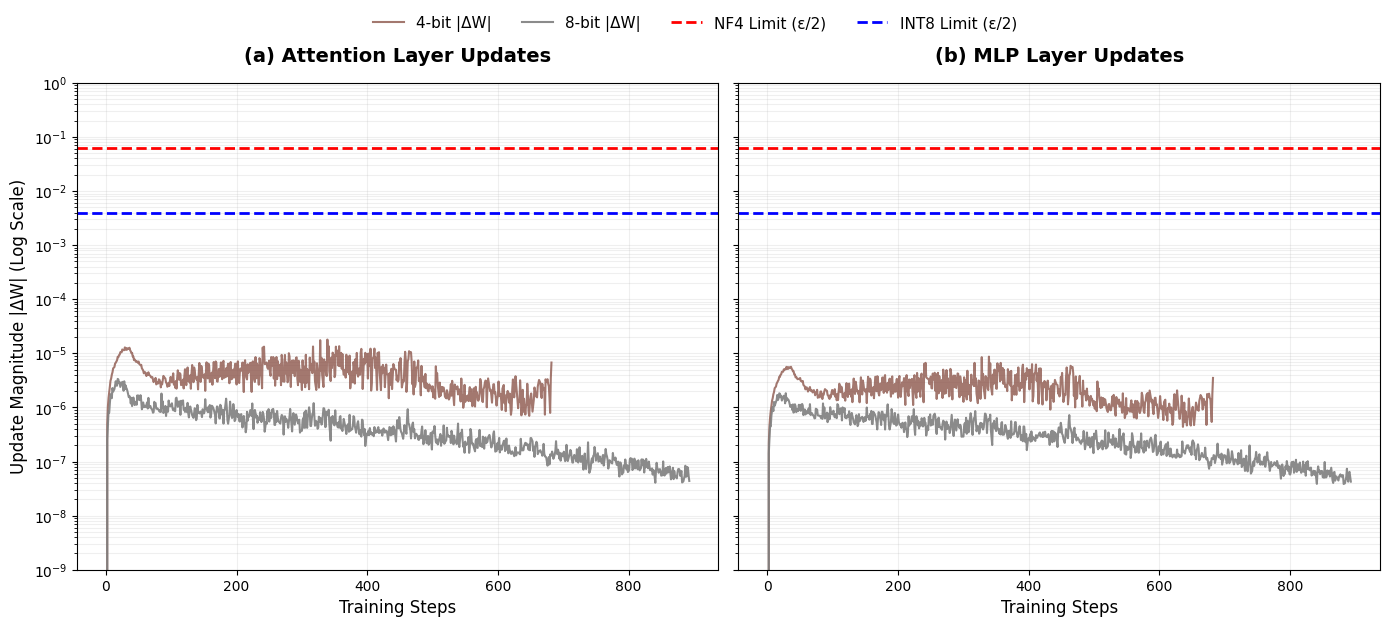

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import sys

def generate_surgical_plot(attn_csv, mlp_csv):
    # Set style
    plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman"], "axes.labelsize": 12})
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
    
    # Constants
    RTN_NF4 = 0.0625   
    RTN_INT8 = 0.0039  

    def process_and_plot(ax, file_path, title):
        try:
            df = pd.read_csv(file_path)
        except Exception as e:
            print(f"❌ Error: Could not read {file_path}. {e}")
            return

        # Clean column names
        df.columns = df.columns.str.strip()
        
        # Identify columns using keywords from your specific Index
        col_4bit = [c for c in df.columns if '4bit' in c and 'train/delta_W' in c and '__' not in c]
        col_8bit = [c for c in df.columns if '_8e_' in c and 'train/delta_W' in c and '__' not in c]

        print(f"\n--- Checking {file_path} ---")
        print(f"Found 4-bit column: {col_4bit}")
        print(f"Found 8-bit column: {col_8bit}")

        if not col_4bit or not col_8bit:
            print(f"⚠️ Skipping {title}: Columns not found. Available: {df.columns.tolist()[:3]}...")
            return

        # Plotting
        ax.plot(df['Step'], df[col_4bit[0]], label='4-bit |ΔW|', color='#8c564b', lw=1.5, alpha=0.8) 
        ax.plot(df['Step'], df[col_8bit[0]], label='8-bit |ΔW|', color='#7f7f7f', lw=1.5, alpha=0.9) 
        
        ax.axhline(y=RTN_NF4, color='red', linestyle='--', linewidth=2, label='NF4 Limit (ε/2)')
        ax.axhline(y=RTN_INT8, color='blue', linestyle='--', linewidth=2, label='INT8 Limit (ε/2)')
        
        ax.set_yscale('log')
        ax.set_ylim(1e-9, 1) # Force range to see updates vs thresholds
        ax.set_title(title, fontsize=14, fontweight='bold', pad=15)
        ax.set_xlabel('Training Steps')
        ax.grid(True, which="both", ls="-", alpha=0.2)

    # Execute
    process_and_plot(ax1, attn_csv, "(a) Attention Layer Updates")
    process_and_plot(ax2, mlp_csv, "(b) MLP Layer Updates")
    
    ax1.set_ylabel("Update Magnitude |ΔW| (Log Scale)")

    # Legend
    handles, labels = ax1.get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4, frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.savefig('figure1_discretization_bottleneck.png', dpi=300, bbox_inches='tight')
    print("\n✅ Success! Figure saved as 'figure1_discretization_bottleneck.png'")
    plt.show()

# Run it
generate_surgical_plot('delta_w_attention.csv', 'delta_w_mlp.csv')